<div style="text-align:center; border-radius:20px; padding:25px; color:white; margin:0; font-family:sans-serif; background:#1b002a; box-shadow:0px 6px 18px rgba(0,0,0,0.35); margin-bottom:1em;">
          <div style="font-size:200%; color:#FEE100; font-weight:700;">
            ai-and-data-science-job-market-dataset-20202026-ETL,EDA,Visualize
          </div>
        </div>
        

![Dataset Image](https://holosen.net/api/file/ca62287a-0ee7-47f8-aa79-495600fa2d1f)


In [1]:
import os
main_csv_local_path = 'AI Job Market Dataset.csv'
DATA_DIR = ''
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename == main_csv_local_path:
            DATA_DIR = os.path.join(dirname, filename)
            print(DATA_DIR)


/kaggle/input/datasets/shree0910/ai-and-data-science-job-market-dataset-20202026/AI Job Market Dataset.csv


Dataset Shape: (10345, 19)

First 5 rows:
   job_id                  job_title company_size company_industry    country  \
0       1                AI Engineer      Startup           Retail     Canada   
1       2  Machine Learning Engineer          MNC       Technology  Australia   
2       3  Machine Learning Engineer          MNC       Technology    Germany   
3       4           Business Analyst      Startup       Healthcare    Germany   
4       5             Data Scientist          MNC       Healthcare    Germany   

  remote_type experience_level  years_experience education_level  \
0      Remote           Senior                 2          Master   
1      Hybrid              Mid                 0        Bachelor   
2      Onsite              Mid                14          Master   
3      Remote              Mid                 9          Master   
4      Hybrid              Mid                 5          Master   

   skills_python  skills_sql  skills_ml  skills_deep_learning 

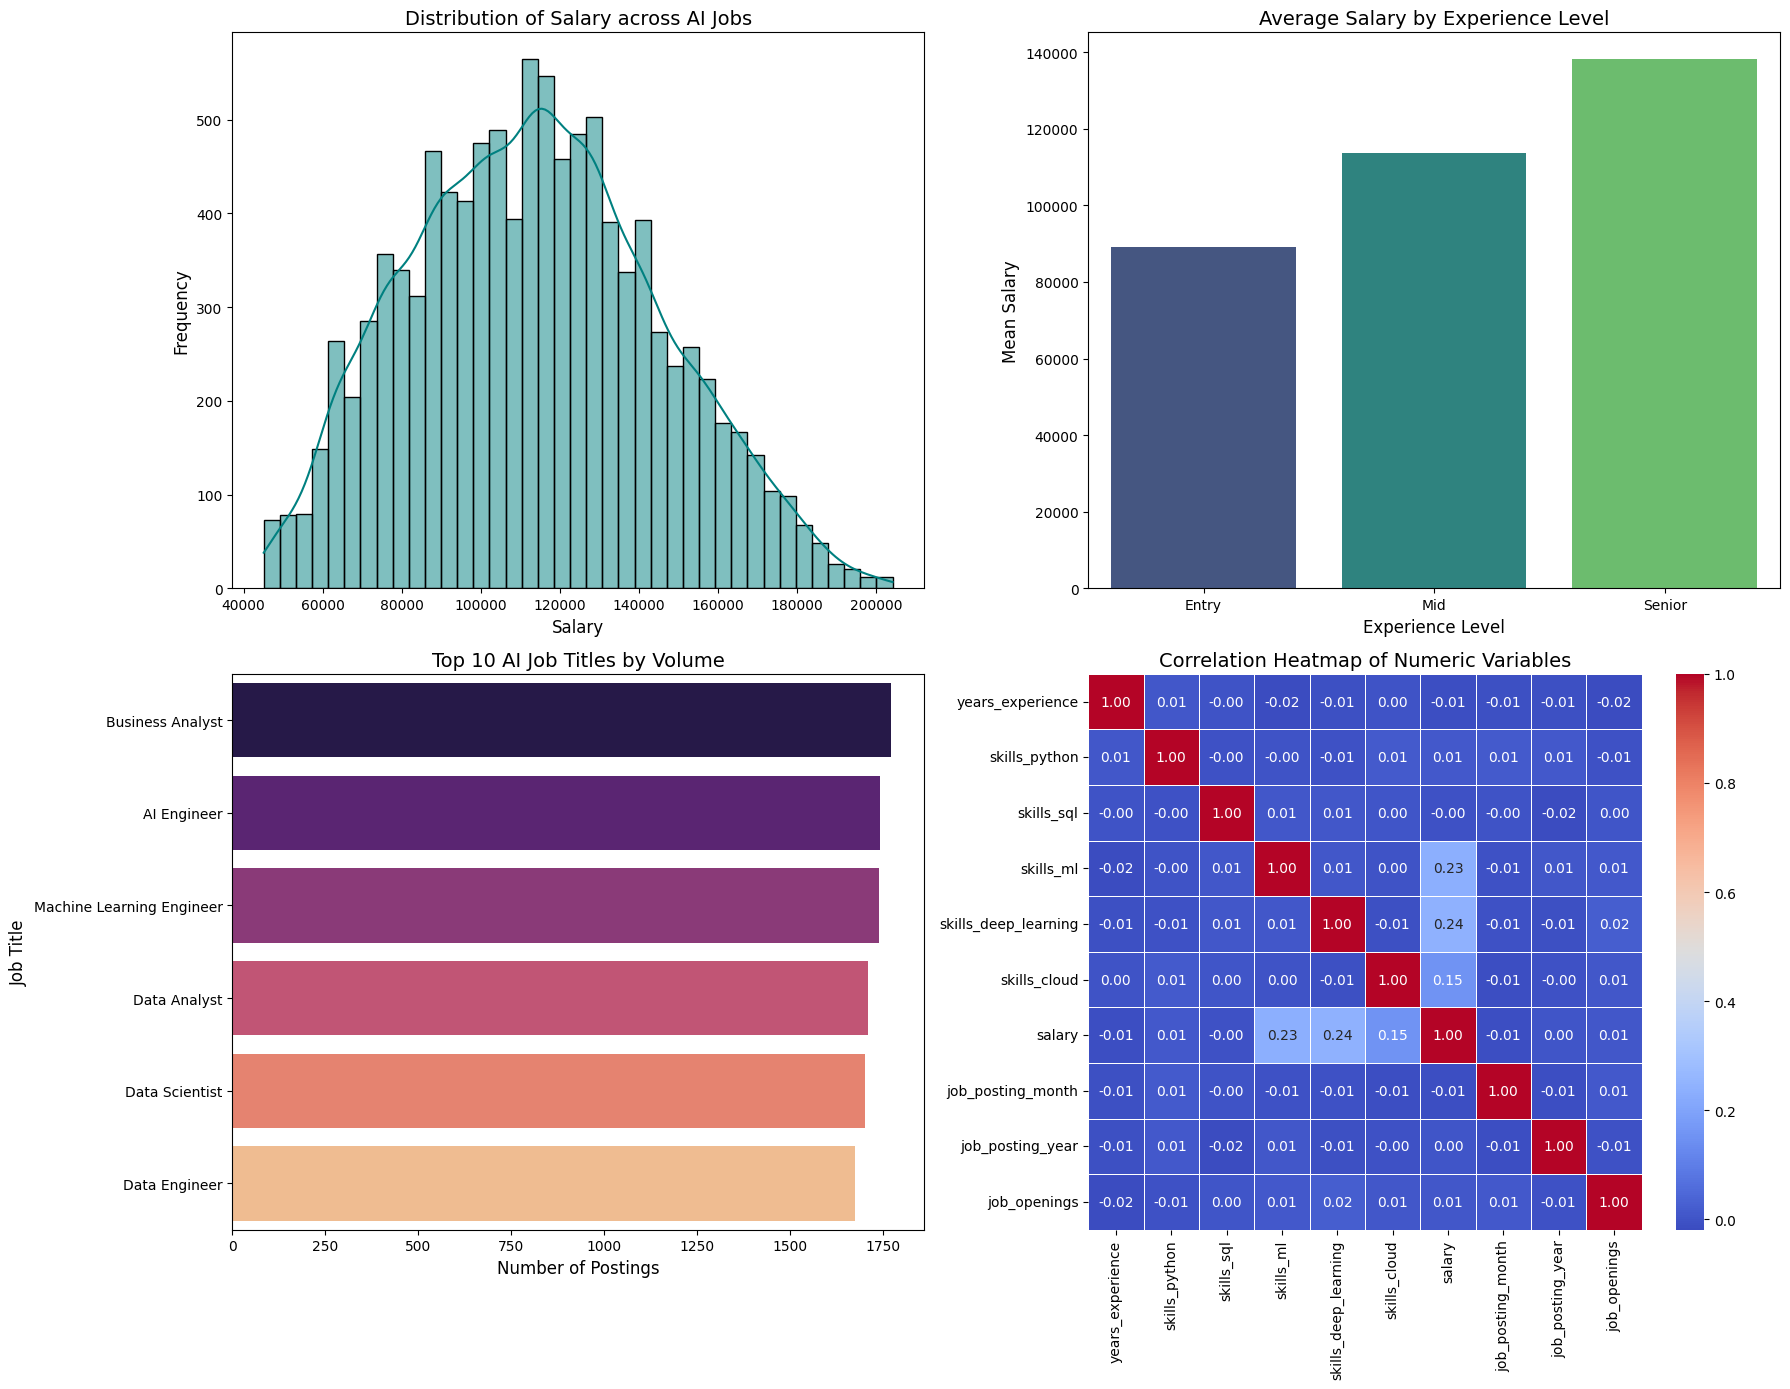

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset using the existing DATA_DIR variable
df = pd.read_csv(DATA_DIR)

# Initial dataset inspection
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Information:")
print(df.info())

# ETL - Data Cleaning and Type Casting
# Remove job_id as it's a unique identifier with no statistical value
if 'job_id' in df.columns:
    df = df.drop(columns=['job_id'])

# Handle missing values by dropping rows with any nulls (safe ETL default)
df = df.dropna()

# Explicitly cast numeric columns to ensure consistency
numeric_cols = [
    'years_experience', 'salary', 'job_openings', 
    'job_posting_month', 'job_posting_year',
    'skills_python', 'skills_sql', 'skills_ml', 
    'skills_deep_learning', 'skills_cloud'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# EDA - Summary Statistics
print("\nSummary Statistics for Numeric Columns:")
print(df.describe())

# EDA - Value Counts for Key Categorical Features
print("\nExperience Level Distribution:")
print(df['experience_level'].value_counts())

# Visualization - 2x2 Grid Layout
plt.figure(figsize=(18, 14))

# 1. Salary Distribution
plt.subplot(2, 2, 1)
sns.histplot(df['salary'], kde=True, color='teal')
plt.title('Distribution of Salary across AI Jobs', fontsize=14)
plt.xlabel('Salary', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# 2. Average Salary by Experience Level
plt.subplot(2, 2, 2)
avg_salary_exp = df.groupby('experience_level')['salary'].mean().sort_values().reset_index()
sns.barplot(
    data=avg_salary_exp, 
    x='experience_level', 
    y='salary', 
    hue='experience_level', 
    palette='viridis', 
    legend=False
)
plt.title('Average Salary by Experience Level', fontsize=14)
plt.xlabel('Experience Level', fontsize=12)
plt.ylabel('Mean Salary', fontsize=12)

# 3. Job Title Popularity (Top 10)
plt.subplot(2, 2, 3)
top_titles = df['job_title'].value_counts().nlargest(10).reset_index()
top_titles.columns = ['job_title', 'count']
sns.barplot(
    data=top_titles, 
    y='job_title', 
    x='count', 
    hue='job_title', 
    palette='magma', 
    legend=False
)
plt.title('Top 10 AI Job Titles by Volume', fontsize=14)
plt.xlabel('Number of Postings', fontsize=12)
plt.ylabel('Job Title', fontsize=12)

# 4. Correlation Heatmap
plt.subplot(2, 2, 4)
# numeric_only=True ensures compatibility with current pandas versions
corr_matrix = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Variables', fontsize=14)

plt.tight_layout()
plt.savefig('ai_job_market_eda.png')

# Final Data Sample Display
print("\nFinal Processed Data Sample:")
print(df.sample(min(5, len(df))))
